# LightGBM — IEEE-CIS Fraud Detection

Metric: **ROC-AUC** and **PR-AUC** (fraud is ~3.5%, so accuracy is misleading).

## 1. Setup and authentication

In [1]:
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery
import pandas as pd, numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score

import os

# --- Project ID is never hardcoded; it is read from Colab Secrets or a .env file ---
# Colab: open the key icon (Secrets) in the left sidebar > add GCP_PROJECT_ID.
# Local: put a .env in the project root (see .env.example) -> GCP_PROJECT_ID=...
PROJECT = None
try:
    from google.colab import userdata            # Colab Secrets
    PROJECT = userdata.get("GCP_PROJECT_ID")
except Exception:
    pass
if not PROJECT:
    try:
        from dotenv import load_dotenv            # local .env
        load_dotenv()
    except Exception:
        pass
    PROJECT = os.environ.get("GCP_PROJECT_ID")
if not PROJECT:
    raise ValueError(
        "GCP_PROJECT_ID not found. Set it via Colab Secrets (key icon) or, "
        "locally, in a .env file."
    )

RANDOM_STATE = 42
client = bigquery.Client(project=PROJECT)
print("Ready.")

Ready.


## 2. Load data

In [2]:
df = client.query(f"SELECT * FROM `{PROJECT}.fraud.train_zengin`").to_dataframe()

# For memory: float64 -> float32, int64 -> int32
for c in df.columns:
    if df[c].dtype == 'float64':
        df[c] = df[c].astype('float32')
    elif df[c].dtype == 'int64':
        df[c] = df[c].astype('int32')

print("Data loaded. Shape:", df.shape)

Data loaded. Shape: (590540, 409)


### 3. Data preparation (LightGBM)

LightGBM **handles missing values (NaN) and categorical columns itself** → impute, scale, or One-Hot Encode is **not needed**. All we do is convert String columns to the `category` dtype and **split first** (same `random_state=42` as LR, for a fair comparison).

In [3]:
import gc

y = df['isFraud']
X = df.drop(columns=['isFraud', 'TransactionID', 'uid'], errors='ignore')
del df; gc.collect()

# Convert String columns to 'category' -> LightGBM uses them as native categoricals
# (no impute/scale/one-hot NEEDED; the model handles NaN and categories itself)
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
for c in categorical_features:
    X[c] = X[c].astype('category')

# Split first, then train (same split as LR -> fair comparison)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
del X; gc.collect()

print("Ready ->", X_train.shape, X_val.shape, "| categorical:", len(categorical_features))

Ready -> (472432, 406) (118108, 406) | categorical: 22


### 4. Training and evaluation

In [4]:
lgbm = lgb.LGBMClassifier(
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=128,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',   # for imbalanced data (fraud ~3.5%)
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# early stopping: stops if the val score doesn't improve for 100 rounds (prevents overfitting)
lgbm.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(200)]
)

proba = lgbm.predict_proba(X_val)[:, 1]
roc = roc_auc_score(y_val, proba)
pr = average_precision_score(y_val, proba)

print("\n=== LightGBM Results ===")
print(f"  ROC-AUC : {roc:.4f}")
print(f"  PR-AUC  : {pr:.4f}")

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 16530, number of negative: 455902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.590043 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 42768
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 405
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Training until validation scores don't improve for 100 rounds
[200]	valid_0's auc: 0.965786	valid_0's binary_logloss: 0.137851
[400]	valid_0's auc: 0.971416	valid_0's binary_logloss: 0.087345
[600]	valid_0's a

### 5. Most important features (bonus)

Which columns the model relies on most when predicting fraud.

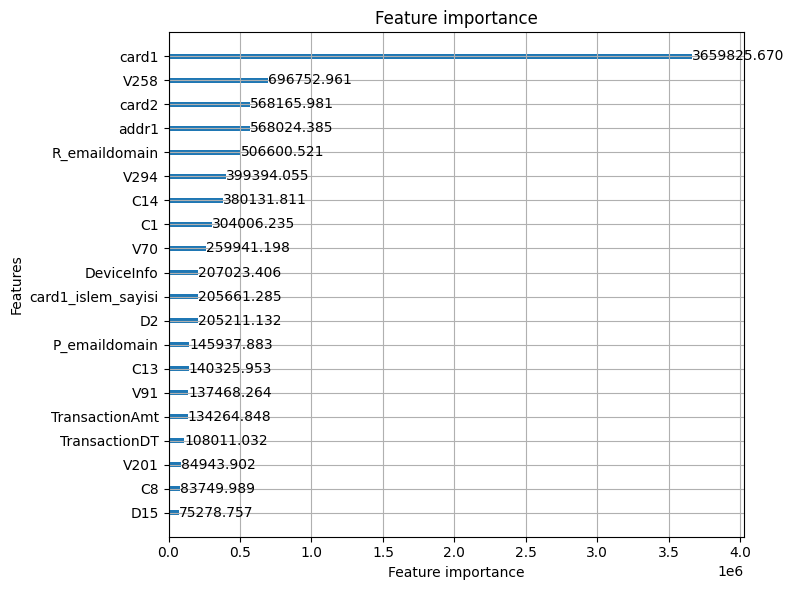

In [5]:
import matplotlib.pyplot as plt

lgb.plot_importance(lgbm, max_num_features=20, importance_type='gain', figsize=(8, 6))
plt.tight_layout(); plt.show()

## Summary

Unlike LR, LightGBM processes raw data (NaN + categorical) directly and captures non-linear / interaction patterns → it yields much higher ROC-AUC / PR-AUC on complex problems like fraud. Fine-tuning: `n_estimators`, `learning_rate`, `num_leaves`.